# The separation manager: detection, resolution, recovery

This notebook generates the three figures on the *Conflict Detection*, *Conflict Resolution* and
*Recovery Criteria* module pages. Every run is no-noise and no-wind, driven by the real
`opencdarr` detector, resolvers and recovery criteria over the real `Multirotor` loop, so what the
handbook shows is what the library does.

We build one figure per stage:

1. **Detection** — state-based CPA in the relative frame, and the breach window against the look-ahead.
2. **Resolution** — MVP against VO on one pairwise conflict, ground tracks and cross-track detour.
3. **Recovery** — Past-CPA against FTR at two crossing angles, and when each lets go.

Figures are also written into `docs/assets/img/` of the site repo when it is checked out beside
this one.


In [1]:
%matplotlib inline
import math
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 130

from opencdarr import geo
from opencdarr.cd import StateBased
from opencdarr.cr import MVP, VO
from opencdarr.cr.base import ConflictResolver
from opencdarr.crr import FTR, PastCPA
from opencdarr.crr.base import RecoveryCriterion
from opencdarr.kinematics import MotionCommand, Multirotor
from opencdarr.performance import M600
from opencdarr.relative import relative_enu
from opencdarr.scenario import create_conflict
from opencdarr.separation import INACTIVE, SeparationManager
from opencdarr.state import AircraftState, DesiredVelocity

LAT0, LON0 = 52.0, 4.0
RPZ, MARGIN, LOOKAHEAD, SPEED = 50.0, 1.05, 120.0, 12.0
BLUE, ORANGE, RED, GREEN, GREY = "#1f77b4", "#ff7f0e", "#d62728", "#2ca02c", "0.55"
_MR = Multirotor()

# Written into the site repo when it is checked out beside this one, so the handbook figures
# stay reproducible from this notebook.
SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"

def save(fig, name):
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)
        print(f"wrote {SITE_IMG / f'{name}.png'}")


def _enu(lat, lon):
    qdr, dist = geo.qdrdist(LAT0, LON0, lat, lon)
    r = math.radians(qdr)
    return dist * math.sin(r), dist * math.cos(r)


def _own(trk=0.0):
    s = AircraftState(id="OWN", lat=LAT0, lon=LON0, trk=trk, gs=SPEED)
    return replace(s, desired=DesiredVelocity.from_track_speed(trk, SPEED))


def _with_intent(s):
    return replace(s, desired=DesiredVelocity.from_track_speed(s.trk, s.gs))

## Detection

We place a 135° crossing conflict with a 25 m projected miss, then read the closest point of
approach and the window the pair spends inside the protected zone. The right panel is the same
encounter as separation over time.


In [2]:
def detection_figure():
    own = _own(0.0)
    intr = create_conflict(own, intr_id="INT", dpsi=135.0, dcpa=25.0, tlos=35.0, rpz=RPZ, side=1)
    rel = relative_enu(own, intr)
    rx, ry, vx, vy = rel.rx, rel.ry, rel.vx, rel.vy
    v = math.hypot(vx, vy)
    t_cpa = -(rx * vx + ry * vy) / (v * v)
    cx, cy = rx + vx * t_cpa, ry + vy * t_cpa
    dcpa = math.hypot(cx, cy)
    tau = math.sqrt(RPZ * RPZ - dcpa * dcpa) / v
    t_in, t_out = t_cpa - tau, t_cpa + tau
    detected = StateBased().detect(own, intr, RPZ, LOOKAHEAD)

    fig, (a_geo, a_sep) = plt.subplots(1, 2, figsize=(11.5, 5.8))

    # --- relative frame: own fixed at origin, the intruder's straight relative track ---
    a_geo.add_patch(plt.Circle((0, 0), RPZ, fill=False, ls="--", color=RED, lw=1.4,
                               label=f"rpz = {RPZ:.0f} m"))
    a_geo.plot(0, 0, "^", color=BLUE, ms=11, zorder=5)
    a_geo.annotate("own", (0, 0), textcoords="offset points", xytext=(9, -3), fontsize=9,
                   color=BLUE)
    seg = [t_in - 11.0, t_out + 16.0]
    a_geo.plot([rx + vx * t for t in seg], [ry + vy * t for t in seg], color=GREY, ls="--",
               lw=1.3, zorder=2)
    a_geo.annotate("", xy=(rx + vx * (t_in + 1.5), ry + vy * (t_in + 1.5)),
                   xytext=(rx + vx * (t_in - 1.5), ry + vy * (t_in - 1.5)),
                   arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=2.2))
    a_geo.annotate("intruder\napproaches", (rx + vx * (t_in - 1.5), ry + vy * (t_in - 1.5)),
                   textcoords="offset points", xytext=(-58, 2), fontsize=9, color=ORANGE)
    for t in (t_in, t_out):
        a_geo.plot(rx + vx * t, ry + vy * t, "o", color=RED, ms=6, zorder=6)
    a_geo.plot([0, cx], [0, cy], color=GREEN, lw=1.8, zorder=4)
    a_geo.plot(cx, cy, "o", color=GREEN, ms=7, zorder=6)
    a_geo.annotate(f"dcpa = {dcpa:.0f} m", (cx / 2, cy / 2), textcoords="offset points",
                   xytext=(6, -2), color=GREEN, fontsize=9)
    a_geo.set_xlim(-110, 130)
    a_geo.set_ylim(-120, 120)
    a_geo.set_aspect("equal")
    a_geo.set_xlabel("relative east [m]")
    a_geo.set_ylabel("relative north [m]")
    a_geo.set_title("Relative frame: the intruder's track and CPA", fontsize=10)
    a_geo.legend(fontsize=9, loc="upper left")

    # --- separation over time: the breach window against the lookahead ---
    tt = [0.1 * k for k in range(int(10 * (t_out + 20)))]
    seps = [math.hypot(rx + vx * t, ry + vy * t) for t in tt]
    a_sep.plot(tt, seps, color=BLUE, lw=2.0)
    a_sep.axhline(RPZ, color=RED, ls="--", lw=1.4, label=f"rpz = {RPZ:.0f} m")
    a_sep.axvspan(t_in, t_out, color=RED, alpha=0.12)
    a_sep.plot(t_cpa, dcpa, "o", color=GREEN, ms=7, zorder=5)
    a_sep.annotate("CPA", (t_cpa, dcpa), textcoords="offset points", xytext=(6, -12),
                   color=GREEN, fontsize=9)
    for t, lbl in ((t_in, "$t_{in}$"), (t_out, "$t_{out}$")):
        a_sep.axvline(t, color=RED, lw=0.9, ls=":")
        a_sep.annotate(lbl, (t, RPZ), textcoords="offset points", xytext=(3, 6), color=RED,
                       fontsize=9)
    a_sep.set_ylim(bottom=0)
    a_sep.set_xlabel("time [s]")
    a_sep.set_ylabel("separation [m]")
    a_sep.set_title("conflict detected" if detected else "no conflict", fontsize=10)
    a_sep.legend(fontsize=9, loc="upper right")
    a_sep.set_box_aspect(1)

    fig.tight_layout()
    save(fig, "cd-detection")

wrote /Users/mfrahman/Projects/opencdarr.github.io/docs/assets/img/cd-detection.png


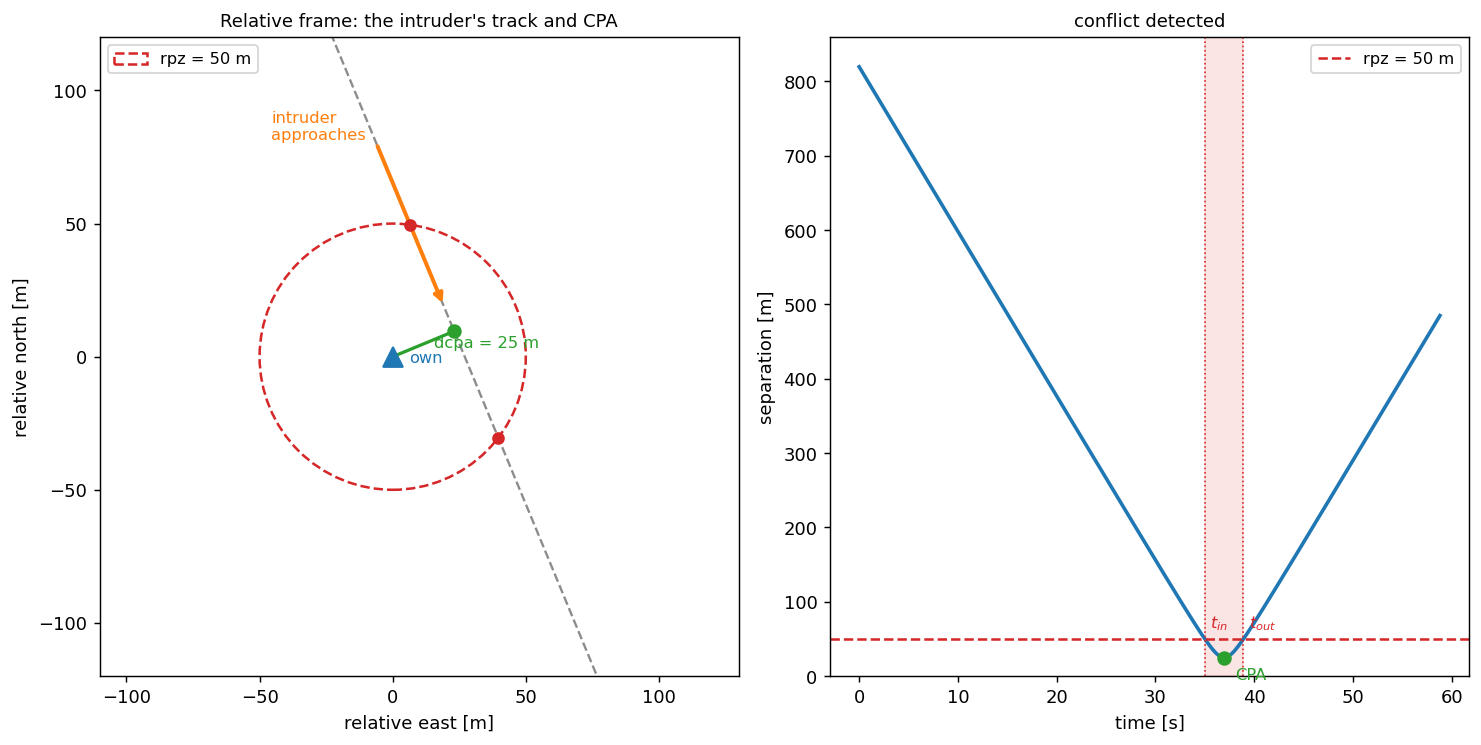

In [3]:
detection_figure()

## Resolution

Both aircraft detect, resolve and recover independently, exactly as `run_encounter` threads them,
so each resolves against the other. The loop below is the shared one for the resolution and
recovery figures.


In [4]:
def _run_pair(resolver: ConflictResolver, recovery: RecoveryCriterion, own0: AircraftState,
              intr0: AircraftState, tmax: float, dt: float = 0.2,
              lookahead: float = LOOKAHEAD) -> dict:
    """One no-noise, no-wind cooperative encounter (both aircraft detect/resolve/recover, exactly
    as the fleet runner threads them). Returns times, separation, both ground tracks, and the timestep at
    which the ownship reverts to its nominal (memory clears)."""
    sep, det = SeparationManager(), StateBased()
    own, intr = own0, intr0
    nom_o = MotionCommand.from_track_speed(own0.trk, own0.gs)
    nom_i = MotionCommand.from_track_speed(intr0.trk, intr0.gs)
    mo = mi = INACTIVE
    co, ci = nom_o, nom_i
    ts, seps, oxy, ixy, resolving = [], [], [], [], []
    onset_idx, resume_idx, prev_resolving, own_resolving = None, None, False, False
    t, nb, i = 0.0, 0.0, 0
    while t < tmax:
        if t + 1e-9 >= nb:
            co, mo = sep.step(own, [intr], nom_o, mo, RPZ, lookahead, det, resolver, recovery)
            ci, mi = sep.step(intr, [own], nom_i, mi, RPZ, lookahead, det, resolver, recovery)
            own_resolving = mo.resolving
            if own_resolving and onset_idx is None:
                onset_idx = i
            if prev_resolving and not own_resolving and resume_idx is None:
                resume_idx = i
            prev_resolving = prev_resolving or own_resolving
            nb += 1.0
        _, d = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        ts.append(t)
        seps.append(d)
        oxy.append(_enu(own.lat, own.lon))
        ixy.append(_enu(intr.lat, intr.lon))
        resolving.append(own_resolving)
        own = replace(_MR.step(own, co, M600, dt), desired=own0.desired)
        intr = replace(_MR.step(intr, ci, M600, dt), desired=intr0.desired)
        t += dt
        i += 1
    return {"ts": ts, "seps": seps, "oxy": oxy, "ixy": ixy, "resolving": resolving,
            "onset": onset_idx, "resume": resume_idx, "min_sep": min(seps)}

We fly the same 90° crossing twice, once resolved by `MVP` and once by `VO`, both with a 1.05 margin and `PastCPA` recovery.


In [5]:
def resolution_figure():
    own = _own(0.0)
    intr = _with_intent(
        create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=0.0, tlos=25.0, rpz=RPZ, side=1))
    mvp_run = _run_pair(MVP(margin=MARGIN), PastCPA(bouncing_guard=True), own, intr, tmax=80.0)
    vo_run = _run_pair(VO(margin=MARGIN), PastCPA(bouncing_guard=True), own, intr, tmax=80.0)

    fig, (a_xy, a_ct) = plt.subplots(1, 2, figsize=(11.5, 5.8))

    # --- ground frame: the two resolved encounters (own bold, intruder faint) ---
    for run, col, lab in ((mvp_run, BLUE, "MVP"), (vo_run, ORANGE, "VO")):
        a_xy.plot([p[0] for p in run["oxy"]], [p[1] for p in run["oxy"]], color=col, lw=2.2,
                  label=f"{lab} own (miss {run['min_sep']:.0f} m)")
        a_xy.plot([p[0] for p in run["ixy"]], [p[1] for p in run["ixy"]], color=col, lw=1.2,
                  alpha=0.45)
    a_xy.plot(mvp_run["oxy"][0][0], mvp_run["oxy"][0][1], "^", color="k", ms=9, zorder=5)
    a_xy.plot(mvp_run["ixy"][0][0], mvp_run["ixy"][0][1], "o", color="0.4", ms=7, zorder=5)
    a_xy.set_aspect("equal")
    a_xy.set_xlabel("east [m]")
    a_xy.set_ylabel("north [m]")
    a_xy.set_title("Ground tracks: own (bold), intruder (faint)", fontsize=10)
    a_xy.legend(fontsize=8, loc="upper right")

    # --- cross-track detour from the nominal (due-north) path over time ---
    for run, col, lab in ((mvp_run, BLUE, "MVP"), (vo_run, ORANGE, "VO")):
        ct = [-p[0] for p in run["oxy"]]  # westward detour magnitude (own turns west)
        a_ct.plot(run["ts"], ct, color=col, lw=2.2, label=f"{lab} (max {max(ct):.0f} m)")
    a_ct.axhline(0.0, color="0.7", lw=0.9)
    a_ct.set_xlabel("time [s]")
    a_ct.set_ylabel("cross-track detour [m]")
    a_ct.set_title("VO gives a wider berth than MVP", fontsize=10)
    a_ct.legend(fontsize=8, loc="upper right")
    a_ct.set_box_aspect(1)

    fig.tight_layout()
    save(fig, "cr-mvp-vs-vo")

wrote /Users/mfrahman/Projects/opencdarr.github.io/docs/assets/img/cr-mvp-vs-vo.png


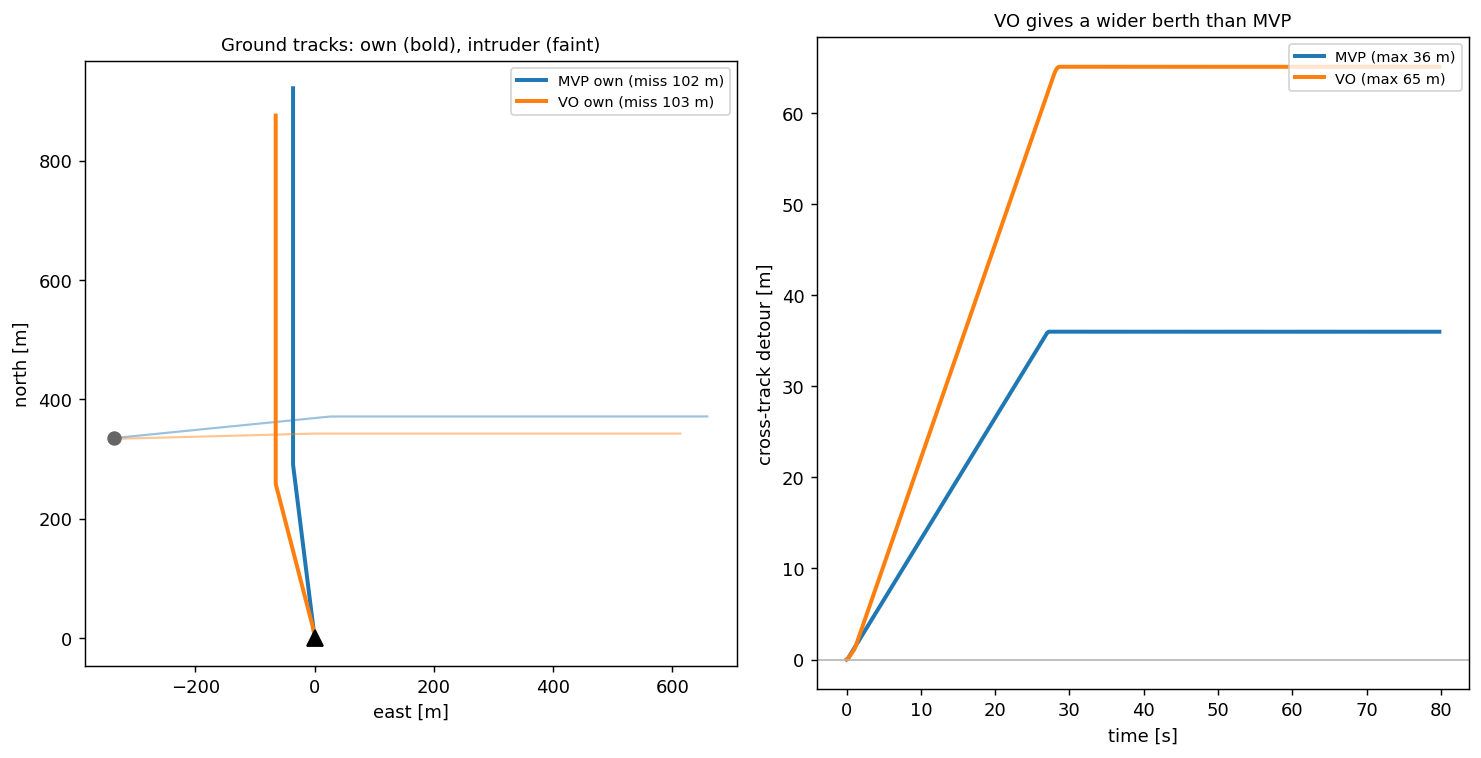

In [6]:
resolution_figure()

## Recovery

The same cooperative loop, now holding the resolver at `MVP` and varying the criterion. The
look-ahead is tuned per scenario so the conflict is detected about 10 s in, giving each run a
nominal lead-in rather than starting already in conflict.


In [7]:
def _resolving_window(run: dict) -> tuple[float, float] | None:
    """The (start, end) times of the ownship's resolving window, or None if it never resolved."""
    o = run["onset"]
    if o is None:
        return None
    end = run["resume"] if run["resume"] is not None else len(run["ts"]) - 1
    return run["ts"][o], run["ts"][end]


def _highlight_path(ax: plt.Axes, pts: list[tuple[float, float]], onset: int | None,
                    resume: int | None, col: str, ls: str, label: str) -> None:
    """One track, faded where the aircraft flies nominal and opaque where it is resolving."""
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.plot(xs, ys, color=col, lw=1.6, ls=ls, alpha=0.35, label=label)  # full path, faded
    if onset is not None:
        end = resume if resume is not None else len(xs) - 1
        ax.plot(xs[onset:end + 1], ys[onset:end + 1], color=col, lw=2.8, ls=ls, alpha=1.0)


def _plot_trajectory(ax: plt.Axes, pc: dict, ft: dict, title: str, ylim: tuple[float, float],
                     xlim: tuple[float, float]) -> None:
    """Both aircraft, both criteria: ownship solid, intruder dashed, colour by criterion. The
    resolving stretch (avoidance active) is drawn opaque and the nominal lead-in / post-revert
    stretches faded, so where each is manoeuvring shows on the path. The east axis is exaggerated
    relative to north (auto aspect): the detour is metres against a kilometre-long leg."""
    for run, col, meth in ((pc, BLUE, "Past-CPA"), (ft, ORANGE, "FTR")):
        _highlight_path(ax, run["oxy"], run["onset"], run["resume"], col, "-", f"{meth} own")
        _highlight_path(ax, run["ixy"], run["onset"], run["resume"], col, "--", f"{meth} intruder")
    ax.plot(pc["oxy"][0][0], pc["oxy"][0][1], "^", color="k", ms=10, zorder=6)
    ax.plot(pc["ixy"][0][0], pc["ixy"][0][1], "v", color="k", ms=10, zorder=6)
    ax.annotate("own start", pc["oxy"][0], textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.annotate("intruder start", pc["ixy"][0], textcoords="offset points", xytext=(6, 4),
                fontsize=8)
    ax.set_aspect("auto")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("east [m]  (exaggerated)")
    ax.set_ylabel("north [m]")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7.5, loc="best")


def _plot_separation(ax: plt.Axes, pc: dict, ft: dict, title: str,
                     xlim: tuple[float, float], ylim: tuple[float, float]) -> None:
    """Separation over time for the two criteria; each criterion's resolving window (avoidance
    active) is shaded in its colour, and the legend carries the revert time and the miss."""
    for run, col, lab in ((pc, BLUE, "Past-CPA"), (ft, ORANGE, "FTR")):
        k = run["resume"]
        tr = run["ts"][k] if k is not None else None
        legend = (f"{lab} (revert {tr:.0f} s, miss {run['min_sep']:.0f} m)" if tr is not None
                  else f"{lab} (miss {run['min_sep']:.0f} m)")
        ax.plot(run["ts"], run["seps"], color=col, lw=2.2, label=legend, zorder=3)
        win = _resolving_window(run)
        if win is not None:
            ax.axvspan(win[0], win[1], color=col, alpha=0.12, lw=0, zorder=0)
    ax.axhline(RPZ, color=RED, ls="--", lw=1.4, label=f"rpz = {RPZ:.0f} m")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("time [s]")
    ax.set_ylabel("separation [m]")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_box_aspect(1)


def _recovery_pair(dpsi: float, tlos: float, tmax: float,
                   lookahead: float) -> tuple[dict, dict]:
    # lookahead is tuned per scenario so the conflict is detected ~10 s in (a nominal lead-in),
    # rather than at t = 0: onset = tlos - lookahead for a dcpa = 0 pair.
    own = _own(0.0)
    intr = _with_intent(
        create_conflict(own, intr_id="INT", dpsi=dpsi, dcpa=0.0, tlos=tlos, rpz=RPZ, side=1))
    pc = _run_pair(MVP(margin=MARGIN), PastCPA(bouncing_guard=True), own, intr, tmax=tmax,
                   lookahead=lookahead)
    ft = _run_pair(MVP(margin=MARGIN), FTR(), own, intr, tmax=tmax, lookahead=lookahead)
    return pc, ft


def recovery_figure():
    # Two crossing angles (rows); left = ground track (own solid, intruder dashed; resolving
    # stretch opaque, nominal faded), right = separation (resolving window shaded). Both start at
    # t = 0 with a ~10 s nominal lead-in: the lookahead is set to tlos - 10 so the conflict is
    # detected then, not at the outset.
    head_pc, head_ft = _recovery_pair(180.0, tlos=50.0, tmax=130.0, lookahead=40.0)
    par_pc, par_ft = _recovery_pair(5.0, tlos=180.0, tmax=470.0, lookahead=170.0)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 11.0))
    _plot_trajectory(axes[0, 0], head_pc, head_ft, "180° head-on: ground track",
                     ylim=(-60.0, 1320.0), xlim=(-70.0, 70.0))
    _plot_separation(axes[0, 1], head_pc, head_ft, "180° head-on: separation",
                     xlim=(0.0, 110.0), ylim=(0.0, 1320.0))
    _plot_trajectory(axes[1, 0], par_pc, par_ft, "5° near-parallel: ground track",
                     ylim=(-60.0, 2600.0), xlim=(-260.0, 260.0))
    _plot_separation(axes[1, 1], par_pc, par_ft, "5° near-parallel: separation",
                     xlim=(0.0, 300.0), ylim=(0.0, 260.0))
    fig.tight_layout()
    save(fig, "crr-pastcpa-vs-ftr")

    def _t(run: dict) -> float:
        return run["ts"][run["resume"]] if run["resume"] is not None else float("nan")
    for tag, pc, ft in (("180 deg", head_pc, head_ft), ("5 deg", par_pc, par_ft)):
        on = head_pc["onset"] if tag == "180 deg" else par_pc["onset"]
        print(f"  {tag}: sep0={pc['seps'][0]:.0f} intr_start=({pc['ixy'][0][0]:.0f},"
              f"{pc['ixy'][0][1]:.0f}) onset={pc['ts'][on] if on else 0:.0f}s  "
              f"PastCPA revert {_t(pc):.0f}s/miss {pc['min_sep']:.0f}, "
              f"FTR {_t(ft):.0f}s/miss {ft['min_sep']:.0f}")

wrote /Users/mfrahman/Projects/opencdarr.github.io/docs/assets/img/crr-pastcpa-vs-ftr.png
  180 deg: sep0=1250 intr_start=(0,1250) onset=10s  PastCPA revert 52s/miss 104, FTR 31s/miss 52
  5 deg: sep0=238 intr_start=(-238,10) onset=10s  PastCPA revert 188s/miss 88, FTR 112s/miss 50


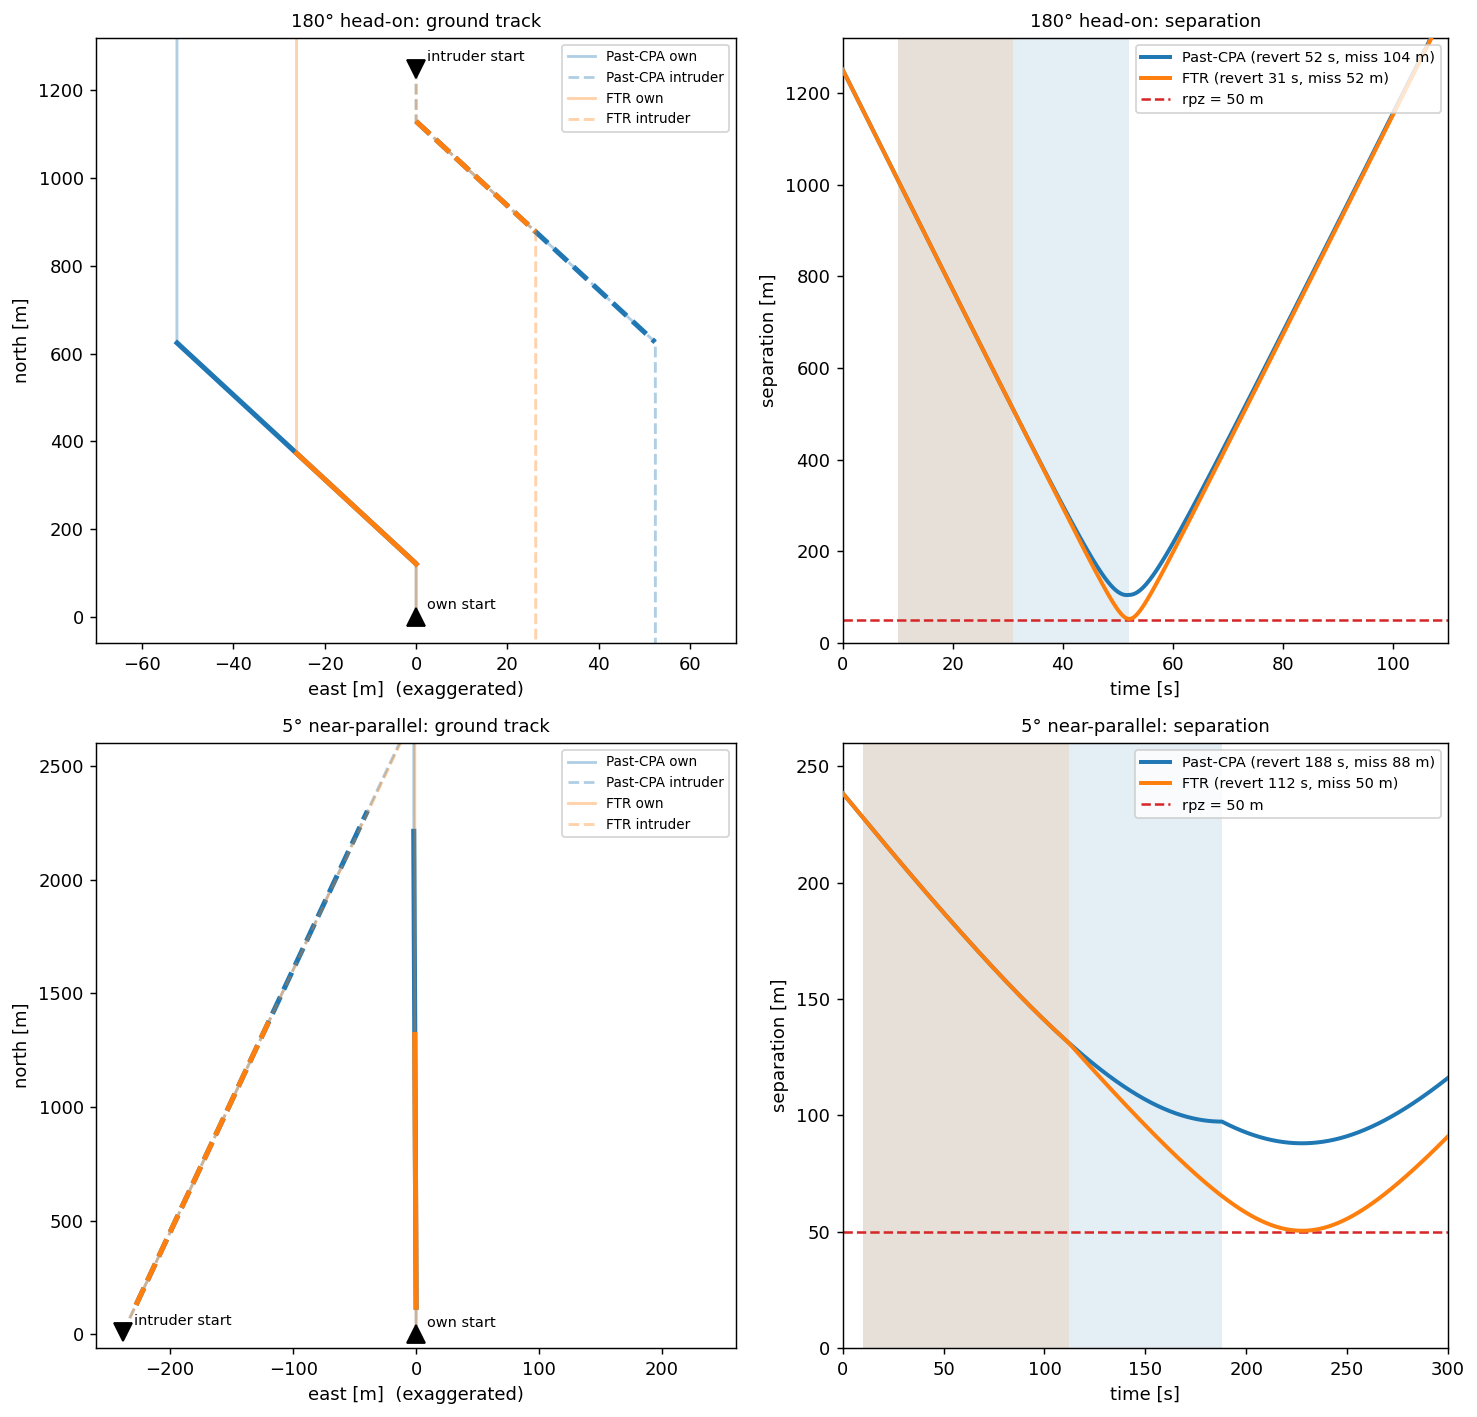

In [8]:
recovery_figure()